# Mixture/Cusp/DDM Model Fitting to Empirical CSD Variance and Bimodality Data

This notebook fits **4 competing theoretical models** to per-level accuracy and embedding variance profiles from CSD (Critical Slowing Down) series data:

1. **Mixture Model** (2-param and 3-param): Models variance as arising from a mixture of competent/incompetent populations
2. **Fold Bifurcation** (baseline): Power-law divergence of variance near a critical point
3. **Cusp Catastrophe**: Nonlinear bifurcation model predicting bimodality near transitions
4. **Drift-Diffusion Model (DDM)**: Logistic accuracy with mixture-derived variance

The analysis runs on 3 representative series (arithmetic, graph-coloring, temperature-sweep) and produces model comparison statistics (R2, AIC, BIC).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, scipy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    # Colab versions: numpy==2.0.2, scipy==1.16.3, matplotlib==3.10.0
    # scipy>=1.16 requires Python>=3.11; use 1.15.3 for Python 3.10 compat
    _pip('numpy==2.0.2', 'scipy==1.15.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import os
import sys
import time
import warnings

import numpy as np
from scipy import integrate, optimize, stats
import matplotlib.pyplot as plt
from loguru import logger

# Configure logging for notebook
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/experiment_iter4_mixture_cusp_dd/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['series'])} series:")
for sid, sdata in data['series'].items():
    print(f"  {sid}: {sdata['n_levels']} levels, task={sdata['task']}, d_star={sdata['d_star']}")

Loaded 3 series:
  arith__gemini-flash: 24 levels, task=arithmetic, d_star=15
  gc__gpt-4o-mini: 20 levels, task=graph_coloring, d_star=10
  temp__T0.7: 24 levels, task=temp_sweep, d_star=2


In [5]:
# ── Configuration ──
# All tunable parameters. Start with minimum values; scale up if time permits.

CURVE_FIT_MAXFEV = 5000       # max function evaluations for scipy curve_fit
CUSP_LBFGSB_MAXITER = 2000    # max iterations for L-BFGS-B cusp optimizer
CUSP_NM_MAXITER = 5000        # max iterations for Nelder-Mead fallback
CUSP_N_PTS = 500              # integration grid points for cusp density
CUSP_X_RANGE = 5.0            # integration range for cusp density
N_CUSP_INITIAL_GUESSES = 4    # number of random restarts for cusp model

# Original values (same as above — this script is lightweight, full params OK)
# CURVE_FIT_MAXFEV = 5000
# CUSP_LBFGSB_MAXITER = 2000
# CUSP_NM_MAXITER = 5000
# CUSP_N_PTS = 500
# N_CUSP_INITIAL_GUESSES = 4

## Helper Functions

Core statistical helpers: R-squared, AIC/BIC computation, and data preparation.

In [6]:
def _compute_r2(observed: np.ndarray, predicted: np.ndarray) -> float:
    """Compute R-squared, handling edge cases."""
    ss_res = np.sum((observed - predicted) ** 2)
    ss_tot = np.sum((observed - np.mean(observed)) ** 2)
    if ss_tot < 1e-15:
        return 0.0
    return float(1.0 - ss_res / ss_tot)


def _compute_aic_bic(n: int, k: int, ss_res: float) -> tuple[float, float]:
    """Compute AIC and BIC from residual sum of squares (Gaussian assumption)."""
    if n <= 0 or ss_res <= 0:
        return float("nan"), float("nan")
    mse = ss_res / n
    log_lik = -n / 2.0 * (np.log(2 * np.pi * mse) + 1.0)
    aic = 2.0 * k - 2.0 * log_lik
    bic = k * np.log(n) - 2.0 * log_lik
    return float(aic), float(bic)


def prepare_series(data: dict) -> dict[str, dict]:
    """Convert loaded JSON data into numpy arrays for each series."""
    all_series = {}
    for sid, sdata in data["series"].items():
        all_series[sid] = {
            "task": sdata["task"],
            "model": sdata["model"],
            "d_star": sdata["d_star"],
            "levels": np.array(sdata["levels"], dtype=float),
            "accuracy": np.array(sdata["accuracy"], dtype=float),
            "variance": np.array(sdata["variance"], dtype=float),
        }
    return all_series

all_series = prepare_series(data)
print(f"Prepared {len(all_series)} series for model fitting")

Prepared 3 series for model fitting


## Model 1: Mixture Model

Fits both 2-param (`Var = p*(1-p)*D^2 + c`) and 3-param (`Var = p*s_c + (1-p)*s_i + p*(1-p)*D^2`) mixture models. Selects the better model by AIC. The mixture model captures the law of total variance decomposition.

In [7]:
def fit_mixture_model(d: np.ndarray, accuracy: np.ndarray, variance: np.ndarray) -> dict:
    """Fit both 2-param and 3-param mixture models. Return best."""
    n = len(d)
    p = accuracy.copy()
    between = p * (1.0 - p)

    nan_result = {
        "D_sq": float("nan"), "s_c": float("nan"), "s_i": float("nan"),
        "c": float("nan"), "R2": float("nan"), "R2_2param": float("nan"),
        "AIC": float("nan"), "BIC": float("nan"),
        "predicted_variance": [float("nan")] * n,
        "peak_accuracy_level": None, "n_params": 0,
    }

    # --- 2-parameter model: Var = p*(1-p)*D_sq + c ---
    r2_2p = float("nan")
    pred_2p = np.full(n, float("nan"))
    d_sq_2p, c_2p = float("nan"), float("nan")

    if np.max(between) >= 1e-10:
        def model_2p(_, d_sq, c):
            return between * d_sq + c
        try:
            popt2, _ = optimize.curve_fit(
                model_2p, d, variance,
                p0=[4 * np.max(variance), np.min(variance)],
                bounds=([0.0, 0.0], [np.inf, np.inf]),
                maxfev=CURVE_FIT_MAXFEV,
            )
            d_sq_2p, c_2p = popt2
            pred_2p = model_2p(d, d_sq_2p, c_2p)
            r2_2p = _compute_r2(variance, pred_2p)
        except (RuntimeError, ValueError):
            pass

    # --- 3-parameter model: Var = p*s_c + (1-p)*s_i + p*(1-p)*D_sq ---
    r2_3p = float("nan")
    pred_3p = np.full(n, float("nan"))
    s_c_3p, s_i_3p, d_sq_3p = float("nan"), float("nan"), float("nan")

    A = np.column_stack([p, 1.0 - p, between])
    try:
        x_nnls, residual = optimize.nnls(A, variance)
        s_c_3p, s_i_3p, d_sq_3p = x_nnls
        pred_3p = A @ x_nnls
        r2_3p = _compute_r2(variance, pred_3p)
    except Exception:
        pass

    # Pick the better model by AIC
    ss_2p = float(np.sum((variance - pred_2p) ** 2)) if not np.isnan(r2_2p) else float("inf")
    ss_3p = float(np.sum((variance - pred_3p) ** 2)) if not np.isnan(r2_3p) else float("inf")

    aic_2p, bic_2p = _compute_aic_bic(n, k=2, ss_res=ss_2p) if np.isfinite(ss_2p) else (float("nan"), float("nan"))
    aic_3p, bic_3p = _compute_aic_bic(n, k=3, ss_res=ss_3p) if np.isfinite(ss_3p) else (float("nan"), float("nan"))

    use_3p = (not np.isnan(aic_3p)) and (np.isnan(aic_2p) or aic_3p < aic_2p)

    if use_3p:
        predicted, r2, aic, bic = pred_3p, r2_3p, aic_3p, bic_3p
        d_sq_best, n_params = d_sq_3p, 3
    elif not np.isnan(r2_2p):
        predicted, r2, aic, bic = pred_2p, r2_2p, aic_2p, bic_2p
        d_sq_best, n_params = d_sq_2p, 2
    else:
        return nan_result

    peak_idx = int(np.argmax(between)) if np.max(between) >= 1e-10 else 0
    peak_level = int(d[peak_idx]) if peak_idx < len(d) else None

    return {
        "D_sq": float(d_sq_best), "s_c": float(s_c_3p), "s_i": float(s_i_3p),
        "c": float(c_2p), "R2": float(r2), "R2_2param": float(r2_2p),
        "AIC": float(aic), "BIC": float(bic),
        "predicted_variance": predicted.tolist(),
        "peak_accuracy_level": peak_level, "n_params": n_params,
    }

print("Mixture model defined")

Mixture model defined


## Model 2: Fold Bifurcation (Baseline)

Power-law divergence model: `Var(d) = A * (d* - d)^gamma + B`. Fits only to pre-transition data (`d < d*`), then extrapolates flat beyond the critical point.

In [8]:
def fit_fold_bifurcation(d: np.ndarray, variance: np.ndarray, d_star: int | None) -> dict:
    """Fit Var_fold(d) = A * (d_star - d)^gamma + B, baseline model."""
    n = len(d)
    if d_star is None:
        d_star = int(d[np.argmax(variance)])

    mask_pre = d < d_star
    n_pre = int(np.sum(mask_pre))

    if n_pre < 3:
        return {
            "A": float("nan"), "B": float("nan"), "gamma": -0.5,
            "R2_pre": float("nan"), "R2_all": float("nan"),
            "AIC": float("nan"), "BIC": float("nan"),
            "n_fitted": n_pre, "valid": False,
            "predicted_variance": [float("nan")] * n,
        }

    d_pre = d[mask_pre]
    var_pre = variance[mask_pre]

    # Fixed gamma = -0.5
    def fold_fixed(x, a, b):
        dist = np.maximum(d_star - x, 1e-6)
        return a * dist ** (-0.5) + b

    try:
        popt_fixed, _ = optimize.curve_fit(
            fold_fixed, d_pre, var_pre, p0=[0.01, np.min(var_pre)],
            bounds=([0, 0], [np.inf, np.inf]), maxfev=CURVE_FIT_MAXFEV)
        a_f, b_f = popt_fixed
        r2_pre_fixed = _compute_r2(var_pre, fold_fixed(d_pre, a_f, b_f))
    except (RuntimeError, ValueError):
        a_f, b_f = float("nan"), float("nan")
        r2_pre_fixed = float("nan")

    # Free gamma
    def fold_free(x, a, b, gamma):
        dist = np.maximum(d_star - x, 1e-6)
        return a * dist ** gamma + b

    try:
        popt_free, _ = optimize.curve_fit(
            fold_free, d_pre, var_pre, p0=[0.01, np.min(var_pre), -0.5],
            bounds=([0, 0, -2], [np.inf, np.inf, 0]), maxfev=CURVE_FIT_MAXFEV)
        a_free, b_free, gamma_free = popt_free
        r2_pre_free = _compute_r2(var_pre, fold_free(d_pre, a_free, b_free, gamma_free))
    except (RuntimeError, ValueError):
        a_free, b_free, gamma_free = float("nan"), float("nan"), float("nan")
        r2_pre_free = float("nan")

    if not np.isnan(r2_pre_free) and (np.isnan(r2_pre_fixed) or r2_pre_free > r2_pre_fixed):
        a_best, b_best, gamma_best = a_free, b_free, gamma_free
        r2_pre, k = r2_pre_free, 3
    else:
        a_best, b_best, gamma_best = a_f, b_f, -0.5
        r2_pre, k = r2_pre_fixed, 2

    try:
        boundary_val = a_best * max(1.0, 1e-6) ** gamma_best + b_best
        pred_all = np.zeros(n)
        for i_pt in range(n):
            if d[i_pt] < d_star:
                dist = max(d_star - d[i_pt], 1e-6)
                pred_all[i_pt] = a_best * dist ** gamma_best + b_best
            else:
                pred_all[i_pt] = boundary_val
        r2_all = _compute_r2(variance, pred_all)
    except Exception:
        r2_all = float("nan")
        pred_all = np.full(n, float("nan"))

    ss_res_pre = float(np.sum((var_pre - (a_best * np.maximum(d_star - d_pre, 1e-6) ** gamma_best + b_best)) ** 2))
    aic, bic = _compute_aic_bic(n_pre, k=k, ss_res=ss_res_pre)

    return {
        "A": float(a_best), "B": float(b_best), "gamma": float(gamma_best),
        "R2_pre": float(r2_pre), "R2_all": float(r2_all),
        "AIC": float(aic), "BIC": float(bic),
        "n_fitted": n_pre, "valid": True,
        "predicted_variance": pred_all.tolist(),
    }

print("Fold bifurcation model defined")

Fold bifurcation model defined


## Model 3: Cusp Catastrophe

Fits a cusp catastrophe model with `alpha(d) = a0 + a1*d`, plus bifurcation parameter `beta` and noise `sigma`. Computes stationary density moments to predict both accuracy and variance simultaneously.

In [9]:
def _cusp_stationary_density(x: np.ndarray, alpha: float, beta: float, sigma: float) -> np.ndarray:
    """Compute unnormalized cusp stationary density at points x."""
    exponent = (2.0 / sigma**2) * (alpha * x + beta * x**2 / 2.0 - x**4 / 4.0)
    exponent -= np.max(exponent)
    return np.exp(exponent)


def _cusp_moments(alpha: float, beta: float, sigma: float,
                  x_range: float = None, n_pts: int = None) -> tuple[float, float, float]:
    """Compute mean, variance, and P(x>0) for the cusp stationary density."""
    if x_range is None: x_range = CUSP_X_RANGE
    if n_pts is None: n_pts = CUSP_N_PTS
    x = np.linspace(-x_range, x_range, n_pts)
    dx = x[1] - x[0]
    density = _cusp_stationary_density(x, alpha, beta, sigma)
    z = np.sum(density) * dx
    if z < 1e-30:
        return 0.0, 0.0, 0.5

    density_norm = density / z
    mean_x = float(np.sum(x * density_norm) * dx)
    var_x = float(np.sum(x**2 * density_norm) * dx - mean_x**2)
    var_x = max(var_x, 0.0)

    p_correct = float(np.sum(density_norm[x > 0]) * dx)
    p_correct = np.clip(p_correct, 0.01, 0.99)

    return mean_x, var_x, p_correct


def fit_cusp_model(d: np.ndarray, accuracy: np.ndarray, variance: np.ndarray) -> dict:
    """Fit cusp catastrophe model: alpha(d) = a0 + a1*d, with beta and sigma."""
    n = len(d)
    d_norm = d / np.max(d)

    var_scale = np.std(variance) if np.std(variance) > 1e-10 else 1.0
    acc_scale = np.std(accuracy) if np.std(accuracy) > 1e-10 else 1.0

    def cusp_loss(params):
        a0, a1, beta, sigma = params
        total_loss = 0.0
        for i, di in enumerate(d_norm):
            alpha_i = a0 + a1 * di
            try:
                _, var_pred, acc_pred = _cusp_moments(alpha_i, beta, sigma)
            except Exception:
                return 1e10
            total_loss += ((acc_pred - accuracy[i]) / acc_scale) ** 2
            total_loss += ((var_pred - variance[i]) / var_scale) ** 2
        return total_loss

    best_result = None
    best_loss = float("inf")

    initial_guesses = [
        [2.0, -4.0, 1.5, 1.0],
        [1.5, -3.0, 2.0, 0.8],
        [3.0, -6.0, 1.0, 1.5],
        [1.0, -2.0, 2.5, 0.5],
    ][:N_CUSP_INITIAL_GUESSES]

    for p0 in initial_guesses:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                result = optimize.minimize(
                    cusp_loss, p0, method="L-BFGS-B",
                    bounds=[(-10, 10), (-20, 0), (0.1, 10), (0.1, 5)],
                    options={"maxiter": CUSP_LBFGSB_MAXITER, "ftol": 1e-10},
                )
            if result.fun < best_loss:
                best_loss = result.fun
                best_result = result
        except Exception:
            continue

    if best_result is None or not best_result.success and best_loss > 1e8:
        try:
            result = optimize.minimize(
                cusp_loss, [2.0, -4.0, 1.5, 1.0], method="Nelder-Mead",
                options={"maxiter": CUSP_NM_MAXITER, "xatol": 1e-8, "fatol": 1e-8},
            )
            if result.fun < best_loss:
                best_loss = result.fun
                best_result = result
        except Exception:
            pass

    if best_result is None:
        return {
            "a0": float("nan"), "a1": float("nan"),
            "beta": float("nan"), "sigma": float("nan"),
            "R2_variance": float("nan"), "R2_accuracy": float("nan"),
            "AIC": float("nan"), "BIC": float("nan"),
            "bimodal_region": None, "cardan_discriminant": [],
            "predicted_variance": [float("nan")] * n,
            "predicted_accuracy": [float("nan")] * n,
        }

    a0, a1, beta, sigma = best_result.x
    raw_var = np.zeros(n)
    raw_acc = np.zeros(n)
    cardan = np.zeros(n)

    for i, di in enumerate(d_norm):
        alpha_i = a0 + a1 * di
        _, var_i, acc_i = _cusp_moments(alpha_i, beta, sigma)
        raw_var[i] = var_i
        raw_acc[i] = acc_i
        cardan[i] = 27 * alpha_i**2 - 4 * beta**3

    # Linear mapping from cusp internal scale to observed scale
    if np.std(raw_var) > 1e-12:
        sv = np.cov(variance, raw_var)[0, 1] / np.var(raw_var)
        ov = np.mean(variance) - sv * np.mean(raw_var)
        pred_var = sv * raw_var + ov
    else:
        pred_var = np.full(n, np.mean(variance))

    if np.std(raw_acc) > 1e-12:
        sa = np.cov(accuracy, raw_acc)[0, 1] / np.var(raw_acc)
        oa = np.mean(accuracy) - sa * np.mean(raw_acc)
        pred_acc = sa * raw_acc + oa
    else:
        pred_acc = np.full(n, np.mean(accuracy))

    r2_var = _compute_r2(variance, pred_var)
    r2_acc = _compute_r2(accuracy, pred_acc)

    ss_res_var = float(np.sum((variance - pred_var) ** 2))
    aic, bic = _compute_aic_bic(n, k=6, ss_res=ss_res_var)

    bimodal_mask = cardan < 0
    if np.any(bimodal_mask):
        bimodal_levels = d[bimodal_mask]
        bimodal_region = [int(bimodal_levels.min()), int(bimodal_levels.max())]
    else:
        bimodal_region = None

    return {
        "a0": float(a0), "a1": float(a1),
        "beta": float(beta), "sigma": float(sigma),
        "R2_variance": float(r2_var), "R2_accuracy": float(r2_acc),
        "AIC": float(aic), "BIC": float(bic),
        "bimodal_region": bimodal_region, "cardan_discriminant": cardan.tolist(),
        "predicted_variance": pred_var.tolist(),
        "predicted_accuracy": pred_acc.tolist(),
    }

print("Cusp catastrophe model defined")

Cusp catastrophe model defined


## Model 4: Drift-Diffusion Model (DDM)

Two-stage fit: (1) logistic sigmoid for accuracy, then (2) variance from DDM-smoothed `p*(1-p)*D^2 + c` using the fitted sigmoid probabilities.

In [10]:
def fit_ddm(d: np.ndarray, accuracy: np.ndarray, variance: np.ndarray) -> dict:
    """Fit DDM: logistic accuracy + mixture variance from fitted sigmoid."""
    n = len(d)

    def sigmoid(x, c0, c1):
        z = c0 + c1 * x
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    try:
        c1_init = -0.5 if accuracy[0] > accuracy[-1] else 0.5
        c0_init = -c1_init * np.mean(d)
        popt_sig, _ = optimize.curve_fit(
            sigmoid, d, accuracy, p0=[c0_init, c1_init],
            bounds=([-50, -50], [50, 50]), maxfev=CURVE_FIT_MAXFEV)
        c0, c1 = popt_sig
    except (RuntimeError, ValueError):
        return {
            "c0": float("nan"), "c1": float("nan"),
            "D_sq": float("nan"), "c_var": float("nan"),
            "R2_accuracy": float("nan"), "R2_variance": float("nan"),
            "AIC": float("nan"), "BIC": float("nan"),
            "implied_d_star": float("nan"),
            "predicted_variance": [float("nan")] * n,
            "predicted_accuracy": [float("nan")] * n,
        }

    acc_pred = sigmoid(d, c0, c1)
    r2_acc = _compute_r2(accuracy, acc_pred)
    between_ddm = acc_pred * (1.0 - acc_pred)

    if np.max(between_ddm) < 1e-10:
        return {
            "c0": float(c0), "c1": float(c1),
            "D_sq": float("nan"), "c_var": float("nan"),
            "R2_accuracy": float(r2_acc), "R2_variance": float("nan"),
            "AIC": float("nan"), "BIC": float("nan"),
            "implied_d_star": float(-c0 / c1) if abs(c1) > 1e-10 else float("nan"),
            "predicted_variance": [float("nan")] * n,
            "predicted_accuracy": acc_pred.tolist(),
        }

    def var_model(_, d_sq, c_var):
        return between_ddm * d_sq + c_var

    try:
        popt_var, _ = optimize.curve_fit(
            var_model, d, variance,
            p0=[4 * np.max(variance), np.min(variance)],
            bounds=([0, 0], [np.inf, np.inf]), maxfev=CURVE_FIT_MAXFEV)
        d_sq, c_var = popt_var
    except (RuntimeError, ValueError):
        d_sq, c_var = float("nan"), float("nan")

    var_pred = var_model(d, d_sq, c_var) if not np.isnan(d_sq) else np.full(n, float("nan"))
    r2_var = _compute_r2(variance, var_pred) if not np.isnan(d_sq) else float("nan")

    ss_res_var = float(np.sum((variance - var_pred) ** 2)) if not np.isnan(d_sq) else float("nan")
    aic, bic = _compute_aic_bic(n, k=4, ss_res=ss_res_var)

    implied_d_star = float(-c0 / c1) if abs(c1) > 1e-10 else float("nan")

    return {
        "c0": float(c0), "c1": float(c1),
        "D_sq": float(d_sq), "c_var": float(c_var),
        "R2_accuracy": float(r2_acc), "R2_variance": float(r2_var),
        "AIC": float(aic), "BIC": float(bic),
        "implied_d_star": float(implied_d_star),
        "predicted_variance": var_pred.tolist() if not np.isnan(d_sq) else [float("nan")] * n,
        "predicted_accuracy": acc_pred.tolist(),
    }

print("DDM model defined")

DDM model defined


## Per-Series Analysis Pipeline

Runs all 4 model fits on each series, performs the prediction test (peak variance vs 50% accuracy), and ranks models by R2 and AIC.

In [11]:
def analyze_series(series_id: str, series_data: dict) -> dict:
    """Run all 4 model fits on one series."""
    t0 = time.time()

    d = series_data["levels"]
    acc = series_data["accuracy"]
    var = series_data["variance"]
    d_star = series_data["d_star"]

    results = {
        "series_id": series_id,
        "task": series_data["task"],
        "model": series_data["model"],
        "n_levels": len(d),
        "d_star": d_star,
    }

    # Fit all 4 models
    results["mixture"] = fit_mixture_model(d, acc, var)
    results["fold"] = fit_fold_bifurcation(d, var, d_star)
    results["cusp"] = fit_cusp_model(d, acc, var)
    results["ddm"] = fit_ddm(d, acc, var)

    # Prediction test: peak variance vs 50% accuracy
    var_peak_idx = int(np.argmax(var))
    d_peak = int(d[var_peak_idx])
    d_50_idx = int(np.argmin(np.abs(acc - 0.5)))
    d_50 = int(d[d_50_idx])

    results["prediction_test"] = {
        "d_peak_empirical": d_peak,
        "d_50pct_accuracy": d_50,
        "accuracy_at_peak": float(acc[var_peak_idx]),
        "match_within_1": abs(d_peak - d_50) <= 1,
        "match_within_2": abs(d_peak - d_50) <= 2,
        "gap": abs(d_peak - d_50),
    }

    # Model ranking by R2
    model_var_r2 = {}
    for model_name in ["mixture", "fold", "cusp", "ddm"]:
        if model_name == "mixture":
            r2_val = results[model_name].get("R2")
        elif model_name == "fold":
            r2_val = results[model_name].get("R2_all")
        else:
            r2_val = results[model_name].get("R2_variance")
        if r2_val is not None and not np.isnan(r2_val):
            model_var_r2[model_name] = r2_val

    if model_var_r2:
        results["best_model_r2"] = max(model_var_r2, key=model_var_r2.get)

    # Model ranking by AIC
    model_aics = {}
    for model_name in ["mixture", "fold", "cusp", "ddm"]:
        aic_val = results[model_name].get("AIC")
        if aic_val is not None and not np.isnan(aic_val):
            model_aics[model_name] = aic_val

    if model_aics:
        results["best_model_aic"] = min(model_aics, key=model_aics.get)

    elapsed = time.time() - t0
    logger.info(
        f"  {series_id}: mixture_R2={results['mixture'].get('R2', float('nan')):.3f}, "
        f"cusp_R2={results['cusp'].get('R2_variance', float('nan')):.3f}, "
        f"best_R2={results.get('best_model_r2', 'N/A')}, "
        f"elapsed={elapsed:.1f}s"
    )
    return results

print("Analysis pipeline defined")

Analysis pipeline defined


## Run Analysis on All Series

Fit all 4 models to each series and compute aggregate statistics.

In [12]:
t_start = time.time()
all_results = []

for sid in sorted(all_series.keys()):
    logger.info(f"Analyzing {sid}...")
    try:
        r = analyze_series(sid, all_series[sid])
        all_results.append(r)
    except Exception as e:
        logger.error(f"Failed on {sid}: {e}")

elapsed = time.time() - t_start
print(f"\nAnalyzed {len(all_results)} series in {elapsed:.1f}s")

10:01:27|INFO   |Analyzing arith__gemini-flash...


10:01:28|INFO   |  arith__gemini-flash: mixture_R2=0.156, cusp_R2=0.372, best_R2=cusp, elapsed=1.5s


10:01:28|INFO   |Analyzing gc__gpt-4o-mini...


10:01:29|INFO   |  gc__gpt-4o-mini: mixture_R2=0.397, cusp_R2=0.004, best_R2=mixture, elapsed=0.5s


10:01:29|INFO   |Analyzing temp__T0.7...


10:01:30|INFO   |  temp__T0.7: mixture_R2=0.189, cusp_R2=0.000, best_R2=mixture, elapsed=1.4s



Analyzed 3 series in 3.4s


## Aggregate Statistics

Compute cross-series comparison: mean R2, win counts, and paired mixture-vs-fold test.

In [13]:
# ── Aggregate statistics ──
n_series = len(all_results)
r2_by_model = {"mixture": [], "fold": [], "cusp": [], "ddm": []}
r2_wins = {"mixture": 0, "fold": 0, "cusp": 0, "ddm": 0}
aic_wins = {"mixture": 0, "fold": 0, "cusp": 0, "ddm": 0}

for r in all_results:
    mix_r2 = r["mixture"].get("R2", float("nan"))
    if not np.isnan(mix_r2): r2_by_model["mixture"].append(mix_r2)
    fold_r2 = r["fold"].get("R2_all", float("nan"))
    if not np.isnan(fold_r2): r2_by_model["fold"].append(max(fold_r2, -1.0))
    cusp_r2 = r["cusp"].get("R2_variance", float("nan"))
    if not np.isnan(cusp_r2): r2_by_model["cusp"].append(cusp_r2)
    ddm_r2 = r["ddm"].get("R2_variance", float("nan"))
    if not np.isnan(ddm_r2): r2_by_model["ddm"].append(ddm_r2)
    best_r2 = r.get("best_model_r2")
    if best_r2: r2_wins[best_r2] += 1
    best_aic = r.get("best_model_aic")
    if best_aic: aic_wins[best_aic] += 1

# Print results table
print("=" * 70)
print("MODEL COMPARISON RESULTS")
print("=" * 70)
print(f"\n{'Series':<25} {'Mixture R2':>10} {'Fold R2':>10} {'Cusp R2':>10} {'DDM R2':>10} {'Best':>8}")
print("-" * 70)
for r in all_results:
    sid = r["series_id"]
    mr = r["mixture"].get("R2", float("nan"))
    fr = r["fold"].get("R2_all", float("nan"))
    cr = r["cusp"].get("R2_variance", float("nan"))
    dr = r["ddm"].get("R2_variance", float("nan"))
    best = r.get("best_model_r2", "N/A")
    print(f"{sid:<25} {mr:>10.4f} {fr:>10.4f} {cr:>10.4f} {dr:>10.4f} {best:>8}")

print("-" * 70)
print(f"\n{'Mean R2:':<25}", end="")
for model in ["mixture", "fold", "cusp", "ddm"]:
    vals = r2_by_model[model]
    mean_val = np.mean(vals) if vals else float("nan")
    print(f" {mean_val:>10.4f}", end="")
print()

print(f"\n{'R2 wins:':<25}", end="")
for model in ["mixture", "fold", "cusp", "ddm"]:
    print(f" {r2_wins[model]:>10}", end="")
print()

print(f"{'AIC wins:':<25}", end="")
for model in ["mixture", "fold", "cusp", "ddm"]:
    print(f" {aic_wins[model]:>10}", end="")
print()

# Prediction test summary
match_1 = sum(1 for r in all_results if r["prediction_test"]["match_within_1"])
match_2 = sum(1 for r in all_results if r["prediction_test"]["match_within_2"])
print(f"\nPrediction test (peak var ~ 50% acc): {match_1}/{n_series} within 1, {match_2}/{n_series} within 2")

MODEL COMPARISON RESULTS

Series                    Mixture R2    Fold R2    Cusp R2     DDM R2     Best
----------------------------------------------------------------------
arith__gemini-flash           0.1559    -0.2212     0.3723     0.0994     cusp
gc__gpt-4o-mini               0.3973     0.0221     0.0041    -0.0000  mixture
temp__T0.7                    0.1886        nan     0.0000     0.0685  mixture
----------------------------------------------------------------------

Mean R2:                      0.2473    -0.0995     0.1255     0.0560

R2 wins:                           2          0          1          0
AIC wins:                          3          0          0          0

Prediction test (peak var ~ 50% acc): 2/3 within 1, 2/3 within 2


## Visualization

Plot observed vs predicted variance for each series across all 4 models, plus a summary bar chart of R2 scores.

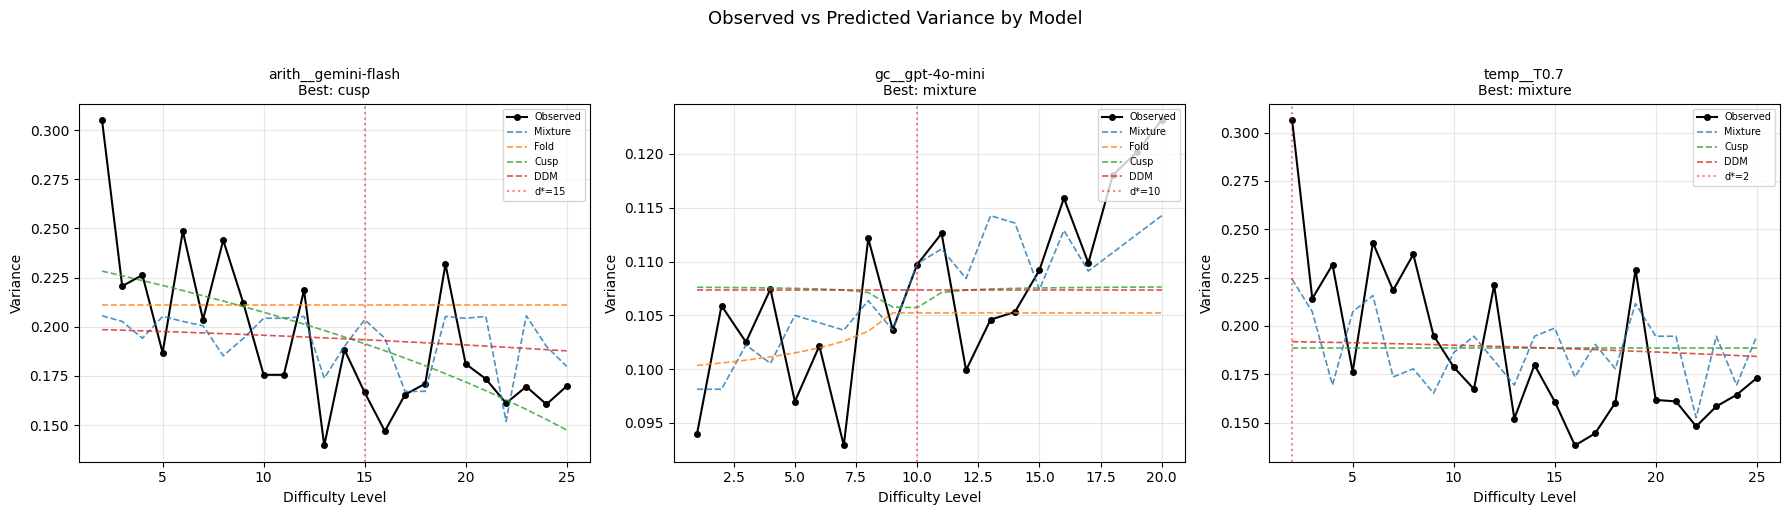

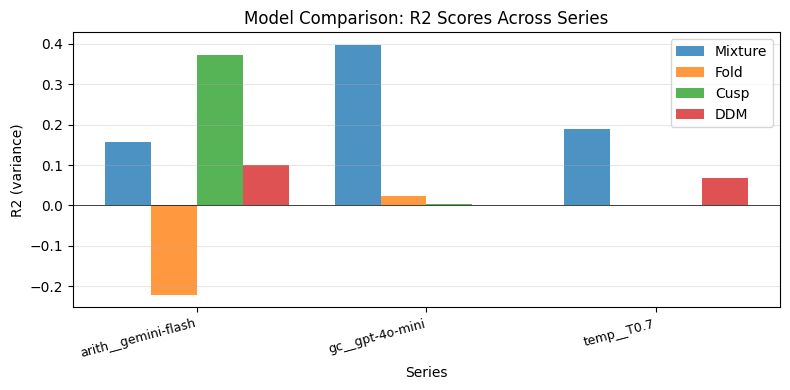

Done!


In [14]:
fig, axes = plt.subplots(1, len(all_results), figsize=(6 * len(all_results), 5), squeeze=False)
axes = axes[0]

for idx, r in enumerate(all_results):
    ax = axes[idx]
    sid = r["series_id"]
    sd = all_series[sid]
    d = sd["levels"]
    var_obs = sd["variance"]

    ax.plot(d, var_obs, 'ko-', label='Observed', markersize=4, linewidth=1.5)

    models_pred = [
        ("Mixture", r["mixture"].get("predicted_variance", []), 'C0'),
        ("Fold", r["fold"].get("predicted_variance", []), 'C1'),
        ("Cusp", r["cusp"].get("predicted_variance", []), 'C2'),
        ("DDM", r["ddm"].get("predicted_variance", []), 'C3'),
    ]
    for name, pred, color in models_pred:
        if pred and len(pred) == len(d):
            pred_arr = np.array(pred)
            if not np.all(np.isnan(pred_arr)):
                ax.plot(d, pred_arr, '--', color=color, label=name, linewidth=1.2, alpha=0.8)

    # Mark d_star
    ax.axvline(r["d_star"], color='red', linestyle=':', alpha=0.5, label=f'd*={r["d_star"]}')

    ax.set_title(f'{sid}\nBest: {r.get("best_model_r2", "N/A")}', fontsize=10)
    ax.set_xlabel('Difficulty Level')
    ax.set_ylabel('Variance')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Observed vs Predicted Variance by Model', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── R2 comparison bar chart ──
fig2, ax2 = plt.subplots(figsize=(8, 4))
model_names = ["Mixture", "Fold", "Cusp", "DDM"]
model_keys = ["mixture", "fold", "cusp", "ddm"]
x_pos = np.arange(len(all_results))
width = 0.2

for i, (mname, mkey) in enumerate(zip(model_names, model_keys)):
    r2_vals = []
    for r in all_results:
        if mkey == "mixture":
            v = r[mkey].get("R2", float("nan"))
        elif mkey == "fold":
            v = r[mkey].get("R2_all", float("nan"))
        else:
            v = r[mkey].get("R2_variance", float("nan"))
        r2_vals.append(v if not np.isnan(v) else 0)
    ax2.bar(x_pos + i * width, r2_vals, width, label=mname, alpha=0.8)

ax2.set_xlabel('Series')
ax2.set_ylabel('R2 (variance)')
ax2.set_title('Model Comparison: R2 Scores Across Series')
ax2.set_xticks(x_pos + 1.5 * width)
ax2.set_xticklabels([r["series_id"] for r in all_results], rotation=15, ha='right', fontsize=9)
ax2.legend()
ax2.axhline(0, color='black', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Done!")